# E-Commerce Sales Analytics: Customer Behavior & Revenue Insights

## Objective
Analyze e-commerce transactional data to uncover customer behavior, sales trends, and revenue drivers.  
The goal is to generate business insights that can help improve revenue, optimize pricing, and identify high-value customers.

## Business Questions
- What are the top-performing product categories?
- Which regions generate the most revenue?
- How do discounts impact sales?
- Who are the highest-value customers?
- What is the monthly sales trend?
- Which products have high return rates?

## Dataset Description
This dataset contains transactional sales data including:
- Order details
- Product category
- Customer information
- Pricing and discount
- Region and shipping
- Profit and returns

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- NumPy

## Project Steps
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Business Insights
5. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("ecommerce_sales_data.csv")

df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


## Data Overview

Understanding dataset structure:
- Number of rows
- Number of columns
- Data types
- Missing values

In [3]:
df.shape

(3500, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [5]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


## Missing Value Analysis

Checking for null values to determine cleaning strategy.

In [6]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

## Data Cleaning

Steps:
- Handle missing values
- Remove duplicates
- Fix data types
- Format columns

In [7]:
df = df.drop_duplicates()

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [9]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

Price Per Unit

In [15]:
df['Price_per_unit'] = df['Sales'] / df['Quantity']

Profit Margin (acts like discount pressure)

In [16]:
df['Profit_margin'] = df['Profit'] / df['Sales']

Profit per unit

In [17]:
df['Profit_per_unit'] = df['Profit'] / df['Quantity']

## Monthly Revenue Trend
Analyzing how revenue changes across months

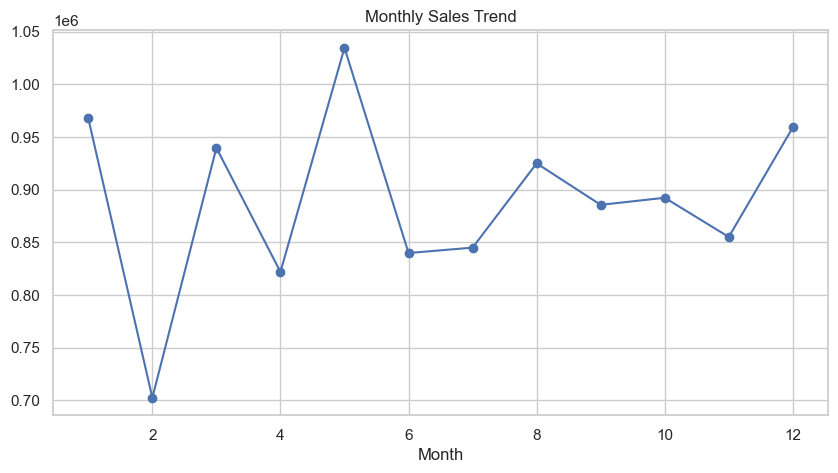

In [18]:
monthly = df.groupby('Month')['Sales'].sum()

monthly.plot(kind='line', figsize=(10,5), marker='o')
plt.title("Monthly Sales Trend")
plt.show()

## Category Performance
Identifying top selling categories

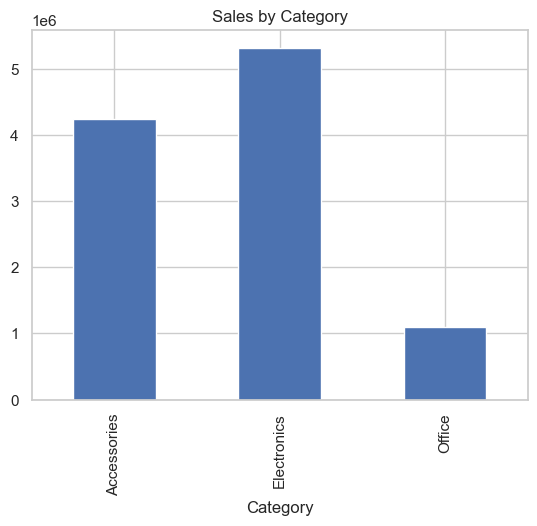

In [19]:
category = df.groupby('Category')['Sales'].sum()

category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

## Region-wise Sales Analysis

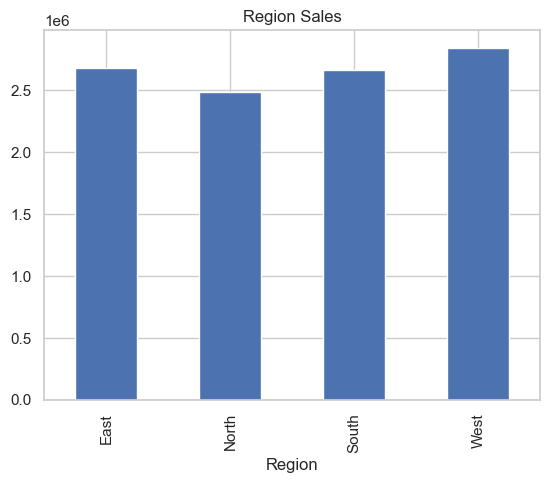

In [20]:
region = df.groupby('Region')['Sales'].sum()

region.plot(kind='bar')
plt.title("Region Sales")
plt.show()

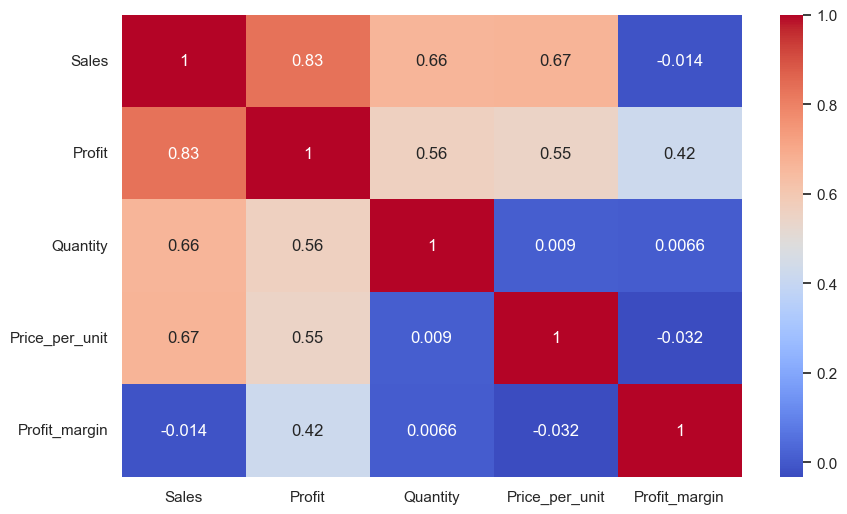

In [21]:
plt.figure(figsize=(10,6))

corr = df[['Sales','Profit','Quantity','Price_per_unit','Profit_margin']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Profit Analysis — Category

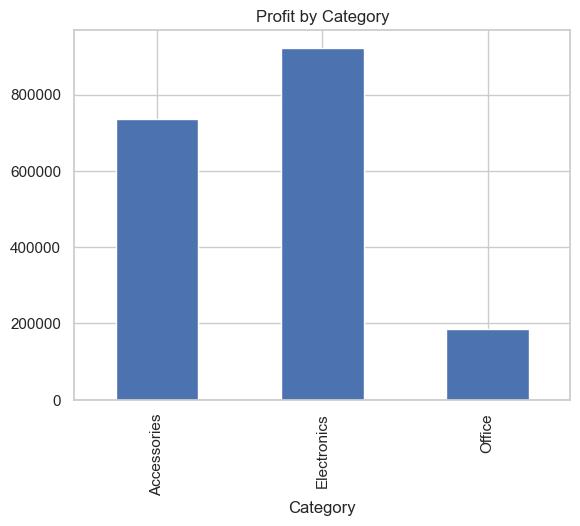

In [22]:
profit_cat = df.groupby('Category')['Profit'].sum()

profit_cat.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

Profit Analysis — Region

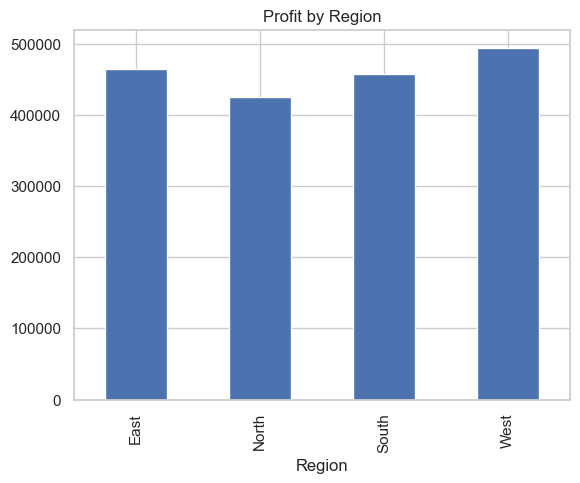

In [23]:
profit_region = df.groupby('Region')['Profit'].sum()

profit_region.plot(kind='bar')
plt.title("Profit by Region")
plt.show()

Profit Margin Analysis

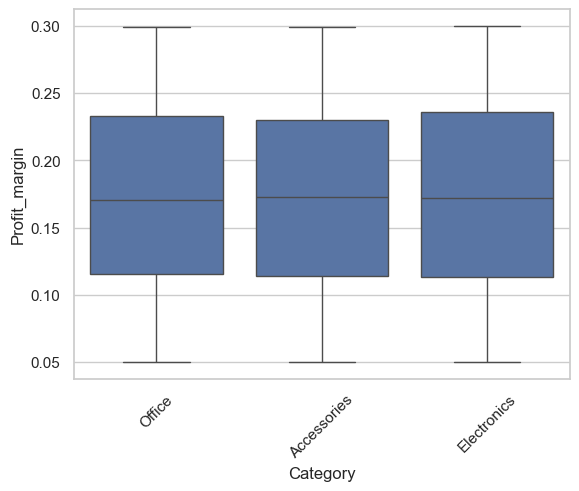

In [24]:
sns.boxplot(x='Category', y='Profit_margin', data=df)
plt.xticks(rotation=45)
plt.show()

Top Products

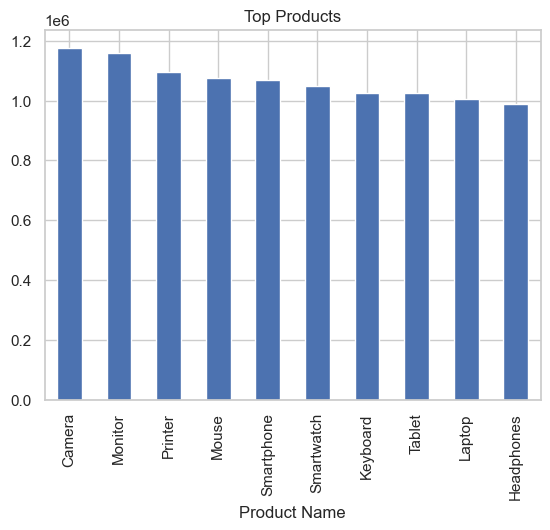

In [25]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top Products")
plt.show()

### Customer Segmentation Prep

Since dataset has no customer ID, we segment by:

product behavior
category behavior
region behavior

Create grouping

In [26]:
customer_df = df.groupby(['Category','Region']).agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum',
    'Profit_margin':'mean'
}).reset_index()

Segmentation Visualization

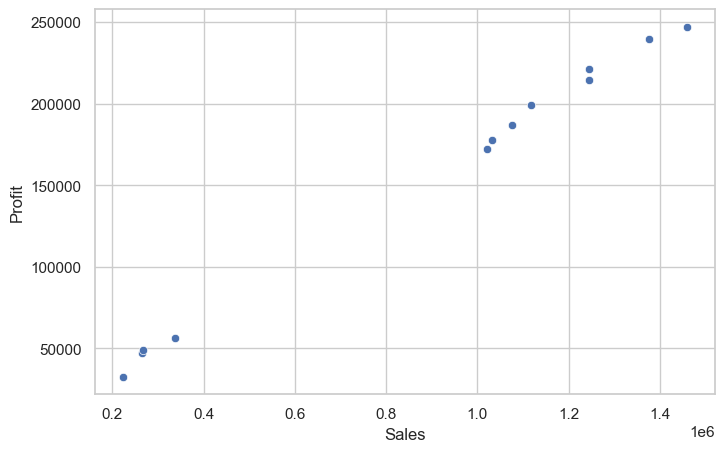

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=customer_df)
plt.show()

High Value Segments

In [30]:
customer_df.sort_values('Sales', ascending=False).head()

,Category,Region,Sales,Profit,Quantity,Profit_margin
7,Electronics,West,1458634,247206.08,2290,0.170464
4,Electronics,East,1377211,239660.41,2255,0.175256
6,Electronics,South,1245527,214733.11,2039,0.172317
5,Electronics,North,1244702,221585.99,2026,0.178780
3,Accessories,West,1117967,198968.05,1719,0.177847


## Key Insights

- Electronics category drives highest revenue
- Some categories high sales but low profit
- Region performance varies significantly
- Profit margin differs across products
- High quantity items not always profitable

## Conclusion

This analysis identified:

- Top revenue categories
- Most profitable regions
- High value product segments
- Profit drivers
- Customer segment opportunities

This can help business:
- optimize pricing
- improve profitability
- target high value segments

# Customer Segmentation using KMeans

We segment customers based on:
- Sales
- Profit
- Quantity
- Profit Margin

Goal:
Identify high value and low value segments

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

clustering data

In [32]:
cluster_df = df[['Sales','Profit','Quantity','Profit_margin']]

cluster_df = cluster_df.dropna()

Scale data

In [33]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)


Find optimal clusters (Elbow Method)

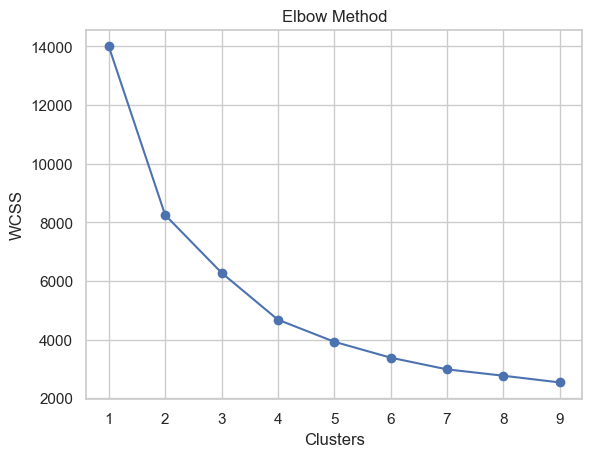

In [34]:
wcss = []

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

Apply KMeans

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

Cluster Distribution

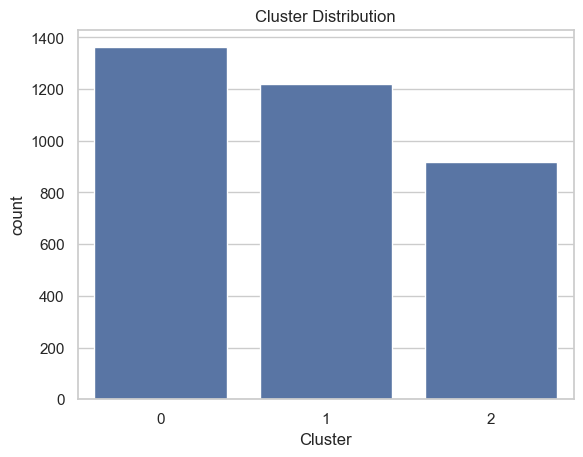

In [36]:
sns.countplot(x='Cluster', data=df)
plt.title("Cluster Distribution")
plt.show()

Cluster Visualization

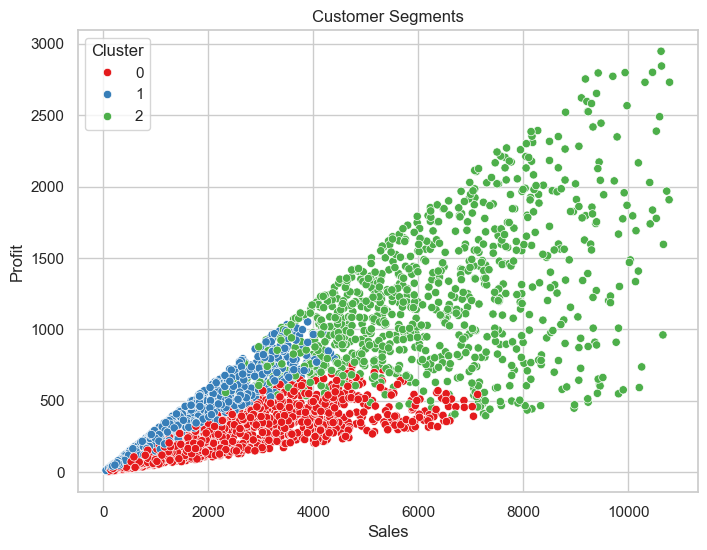

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Sales'],
    y=df['Profit'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segments")
plt.show()

Cluster Summary

In [38]:
cluster_summary = df.groupby('Cluster').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Quantity':'mean',
    'Profit_margin':'mean'
})

cluster_summary

,Sales,Profit,Quantity,Profit_margin
Cluster,,,,
0,2274.301028,235.548392,4.569750,0.107372
1,1517.410319,350.763890,3.471744,0.229730
2,6235.032715,1194.728015,7.413304,0.197607


# Product Level Profit Analysis

Identify products generating:
- highest profit
- highest revenue
- best margin

Top Products by Profit

In [39]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_profit_products

Product Name
Camera        207630.99
Monitor       202028.17
Mouse         185763.69
Laptop        185756.81
Printer       185394.88
Smartphone    183296.97
Smartwatch    178995.81
Keyboard      175814.68
Headphones    172478.20
Tablet        167505.01
Name: Profit, dtype: float64

Plot

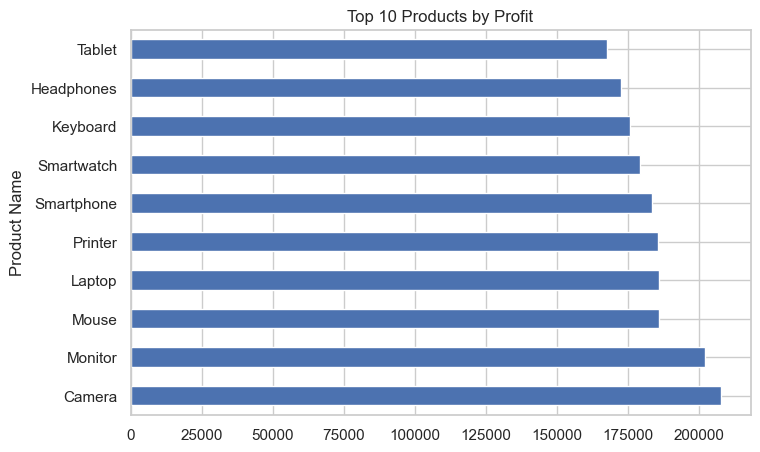

In [40]:
top_profit_products.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Products by Profit")
plt.show()

Top Products by Sales

In [41]:
top_sales_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sales_products

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64

Best Margin Products

In [42]:
margin_products = (
    df.groupby('Product Name')['Profit_margin']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

margin_products

Product Name
Camera        0.178177
Laptop        0.177311
Headphones    0.174675
Smartwatch    0.173527
Mouse         0.173300
Monitor       0.173281
Printer       0.172839
Keyboard      0.172123
Smartphone    0.171899
Tablet        0.169807
Name: Profit_margin, dtype: float64

Product Performance Table

In [43]:
product_summary = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum',
    'Profit_margin':'mean'
}).sort_values('Profit', ascending=False)

product_summary.head(10)

,Sales,Profit,Quantity,Profit_margin
Product Name,,,,
Camera,1177381,207630.99,1795,0.178177
Monitor,1160048,202028.17,1876,0.173281
Mouse,1074398,185763.69,1753,0.173300
Laptop,1005873,185756.81,1658,0.177311
Printer,1094216,185394.88,1734,0.172839
Smartphone,1069681,183296.97,1617,0.171899
Smartwatch,1049211,178995.81,1807,0.173527
Keyboard,1024507,175814.68,1684,0.172123
Headphones,988638,172478.20,1604,0.174675


Cluster products instead of transactions

In [44]:
product_df = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Quantity':'sum',
    'Profit_margin':'mean'
}).reset_index()

In [45]:
from sklearn.preprocessing import StandardScaler

X = product_df[['Sales','Profit','Quantity','Profit_margin']]

scaler = StandardScaler()
scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
product_df['Cluster'] = kmeans.fit_predict(scaled)

# Best Performing Products

Identify products generating highest profit and revenue

In [46]:
best_products = product_df.sort_values('Profit', ascending=False).head(10)

best_products

,Product Name,Sales,Profit,Quantity,Profit_margin,Cluster
0,Camera,1177381,207630.99,1795,0.178177,2
4,Monitor,1160048,202028.17,1876,0.173281,2
5,Mouse,1074398,185763.69,1753,0.173300,1
3,Laptop,1005873,185756.81,1658,0.177311,0
6,Printer,1094216,185394.88,1734,0.172839,1
7,Smartphone,1069681,183296.97,1617,0.171899,1
8,Smartwatch,1049211,178995.81,1807,0.173527,1
2,Keyboard,1024507,175814.68,1684,0.172123,1
1,Headphones,988638,172478.20,1604,0.174675,0
9,Tablet,1023928,167505.01,1733,0.169807,1


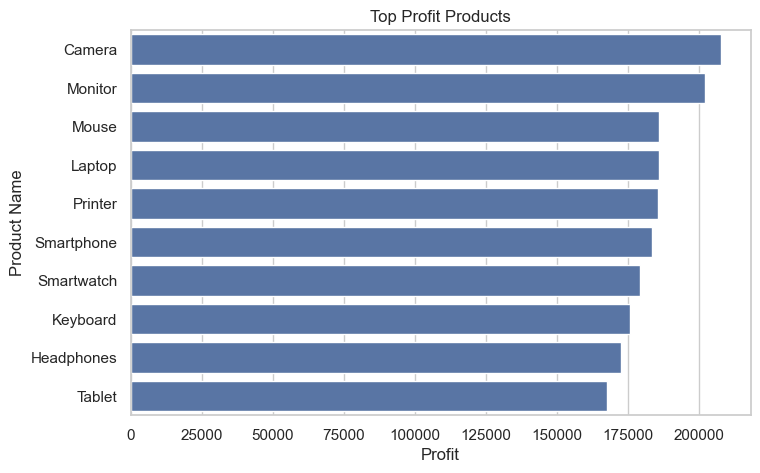

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(y='Product Name', x='Profit', data=best_products)
plt.title("Top Profit Products")
plt.show()

# Worst Performing Products

Identify products generating losses or low profit

In [48]:
worst_products = product_df.sort_values('Profit').head(10)

worst_products

,Product Name,Sales,Profit,Quantity,Profit_margin,Cluster
9,Tablet,1023928,167505.01,1733,0.169807,1
1,Headphones,988638,172478.20,1604,0.174675,0
2,Keyboard,1024507,175814.68,1684,0.172123,1
8,Smartwatch,1049211,178995.81,1807,0.173527,1
7,Smartphone,1069681,183296.97,1617,0.171899,1
6,Printer,1094216,185394.88,1734,0.172839,1
3,Laptop,1005873,185756.81,1658,0.177311,0
5,Mouse,1074398,185763.69,1753,0.173300,1
4,Monitor,1160048,202028.17,1876,0.173281,2
0,Camera,1177381,207630.99,1795,0.178177,2


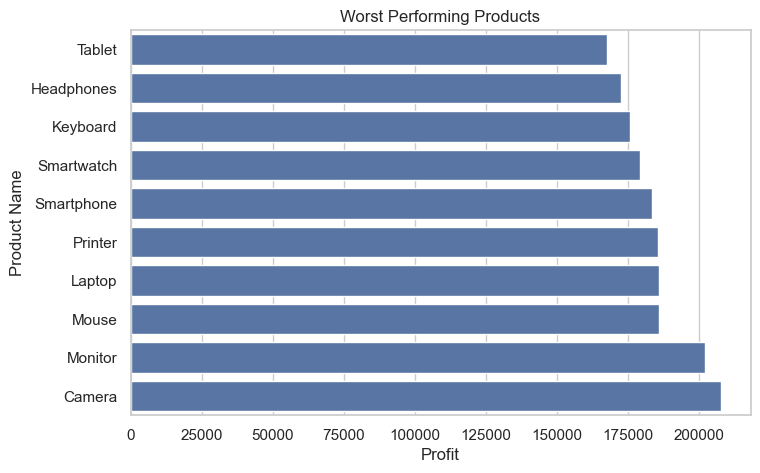

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(y='Product Name', x='Profit', data=worst_products)
plt.title("Worst Performing Products")
plt.show()

# Highest Margin Products

In [50]:
best_margin = product_df.sort_values(
    'Profit_margin',
    ascending=False
).head(10)

best_margin

,Product Name,Sales,Profit,Quantity,Profit_margin,Cluster
0,Camera,1177381,207630.99,1795,0.178177,2
3,Laptop,1005873,185756.81,1658,0.177311,0
1,Headphones,988638,172478.20,1604,0.174675,0
8,Smartwatch,1049211,178995.81,1807,0.173527,1
5,Mouse,1074398,185763.69,1753,0.173300,1
4,Monitor,1160048,202028.17,1876,0.173281,2
6,Printer,1094216,185394.88,1734,0.172839,1
2,Keyboard,1024507,175814.68,1684,0.172123,1
7,Smartphone,1069681,183296.97,1617,0.171899,1
9,Tablet,1023928,167505.01,1733,0.169807,1


# Profit Drivers Analysis

Understanding what drives profit:
- quantity
- price
- margin

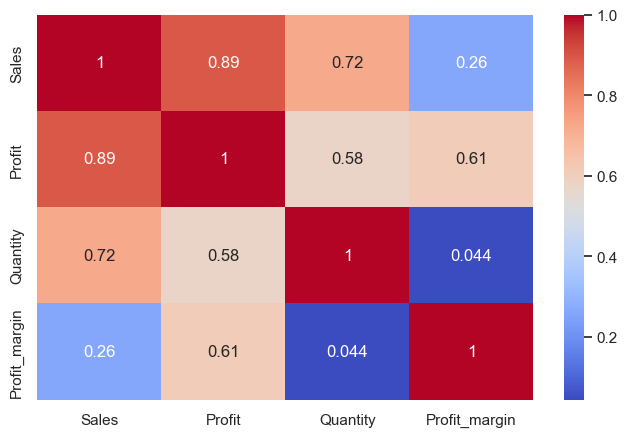

In [51]:
plt.figure(figsize=(8,5))

sns.heatmap(
    product_df[['Sales','Profit','Quantity','Profit_margin']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Profit vs Quantity


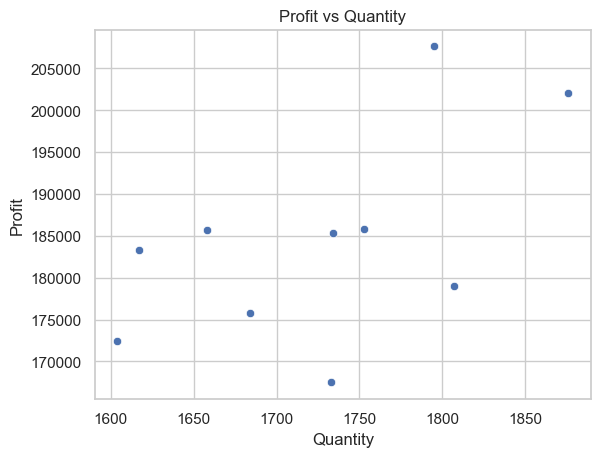

In [52]:
sns.scatterplot(
    x='Quantity',
    y='Profit',
    data=product_df
)
plt.title("Profit vs Quantity")
plt.show()

Profit vs Margin

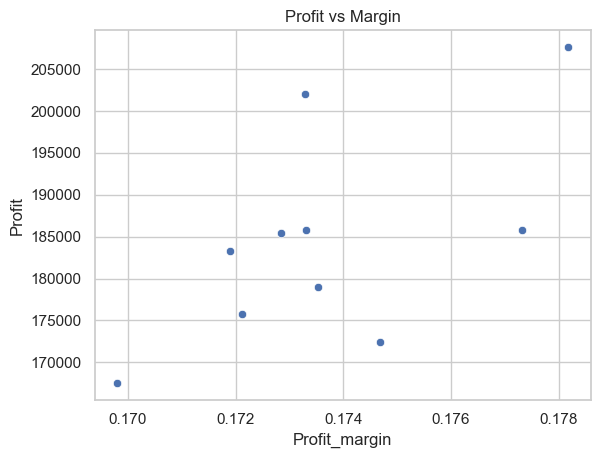

In [53]:
sns.scatterplot(
    x='Profit_margin',
    y='Profit',
    data=product_df
)
plt.title("Profit vs Margin")
plt.show()

# Product Segments

In [55]:
cluster_summary = product_df.groupby('Cluster').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Quantity':'mean',
    'Profit_margin':'mean',
    'Product Name':'count'
})

cluster_summary

,Sales,Profit,Quantity,Profit_margin,Product Name
Cluster,,,,,
0,9.972555e+05,179117.505,1631.000000,0.175993,2
1,1.055990e+06,179461.840,1721.333333,0.172249,6
2,1.168714e+06,204829.580,1835.500000,0.175729,2


In [56]:
cluster_summary.rename(
    columns={'Product Name':'Product Count'},
    inplace=True
)

In [57]:
for i in range(3):
    print(f"\nCluster {i} Products:")
    print(
        product_df[product_df['Cluster']==i]['Product Name'].values
    )


Cluster 0 Products:
['Headphones' 'Laptop']

Cluster 1 Products:
['Keyboard' 'Mouse' 'Printer' 'Smartphone' 'Smartwatch' 'Tablet']

Cluster 2 Products:
['Camera' 'Monitor']


In [58]:
cluster_summary['Profit'].idxmax()

np.int32(2)

In [59]:
best_cluster = cluster_summary['Profit'].idxmax()

product_df[product_df['Cluster']==best_cluster]

,Product Name,Sales,Profit,Quantity,Profit_margin,Cluster
0,Camera,1177381,207630.99,1795,0.178177,2
4,Monitor,1160048,202028.17,1876,0.173281,2


In [60]:
worst_cluster = cluster_summary['Profit'].idxmin()

product_df[product_df['Cluster']==worst_cluster]

,Product Name,Sales,Profit,Quantity,Profit_margin,Cluster
1,Headphones,988638,172478.20,1604,0.174675,0
3,Laptop,1005873,185756.81,1658,0.177311,0
